# Minimal Complexity Self Assembly  
## A Computational Modeling Notebook Inspired by Bio Inspired Nanotechnology

### Project Motivation

This notebook is inspired by the paper *Designing the Self Assembly of Arbitrary Shapes Using Minimal Complexity Building Blocks* by Joakim Bohlin, Andrew J. Turberfield, Ard A. Louis, and Petr Šulc.

The main idea that I found interesting in this paper is that a self assembled structure does not always need a completely unique building block for every position in the final shape. In one possible design, every component can be fully addressable and unique. In another design, the same structure may be represented with a smaller number of reusable building block types, as long as the interactions between them still guide the system toward the intended target structure.

For this notebook, I am using that idea as the starting point for a simplified computational modeling project. I am not trying to reproduce the full scientific pipeline from the paper. Instead, I am building a smaller Python based model that helps me understand the design logic behind minimal complexity self assembly.

### Research Focus

The main question I want to explore is whether a target shape can be represented using fewer distinct building block types while still preserving enough interaction information to describe the intended assembly.

This question is useful because it connects computer science ideas such as graph representation, constraint based thinking, optimization, and simulation with bio inspired nanotechnology. It also provides a way to think about how complex structures can emerge from simpler reusable parts.

### Modeling Approach

In this notebook, I represent target shapes as grid based structures. Each position in the shape is treated as a building block, and each connection between neighboring positions is treated as an interaction. I then compare different ways of assigning building block types and interaction labels to the same target shape.

The goal is to compare a more complex design, where each position is treated as unique, with a simpler design where some building block types can be reused. This allows me to study how design complexity changes when the same final structure is described using fewer distinct components.

### Connection to Sustainability

The original paper is focused on programmable self assembly and bio inspired nanotechnology, but the idea of minimal complexity design also has a broader sustainability connection.

If future nanoscale materials, sensing platforms, or engineered structures can be designed with fewer unique components, this could reduce synthesis burden, material complexity, and trial and error during experimental development. In the long term, these ideas may be relevant to environmental sensing, sustainable materials, and more efficient design workflows for scientific and engineering applications.

For me, this project is a way to connect my interest in sustainability with computational modeling and bio inspired systems in a more research oriented direction.

### Scope of This Notebook

This notebook is a conceptual computational modeling project. It does not attempt to perform molecular dynamics, DNA nanotechnology simulation, or a full SAT based inverse design implementation.

Instead, the purpose is to build a clear and understandable model that captures the broader design idea from the paper: how reusable building blocks and interaction rules can be used to describe a target self assembled structure with lower complexity.

The notebook is meant to be a learning project, but I want it to be structured in a research style so that each step is easy to follow, explain, and improve.

## Step 1: Representing a Target Shape as a Graph

Before comparing complex and minimal designs, I first need a clean way to represent a target structure computationally.

In this simplified notebook, I represent a target shape as a set of occupied grid positions. Each occupied position is treated as one building block. If two occupied positions are directly next to each other, I treat that connection as a required interaction between building blocks.

This gives me a graph representation of the structure, where nodes represent building blocks and edges represent the required bonds or interactions between them.

This is a simplified version of the modeling idea used in the paper. The original work studies polycube structures, SAT based inverse design, stochastic assembly checks, patchy particle simulations, and DNA nanostructure realization. Here, I am starting with a smaller graph based representation so that the design logic is easier to understand and extend.

,Shape,Number of building blocks,Number of required interactions,Average connections per block
0,2 x 2 square,4,4,2.0
1,L shape,4,3,1.5


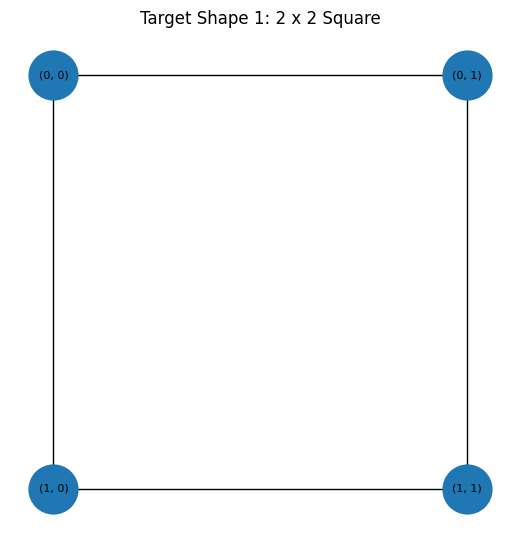

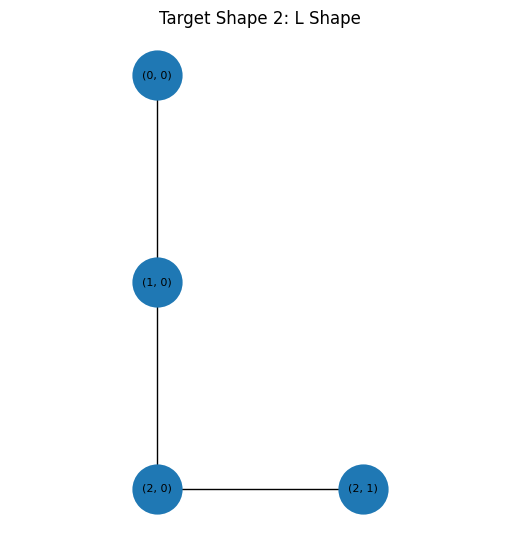

In [1]:
# ============================================================
# Step 1: Representing target shapes as graph based structures
# ============================================================

# What I am doing:
# In this cell, I define simple grid based target shapes and convert them
# into graph representations. Each occupied grid position becomes a node,
# and each direct neighbor connection becomes an edge. This gives a clean
# computational foundation for studying self assembly design complexity.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


def make_shape_from_grid(grid):
    """
    Convert a 2D grid into a list of occupied positions.

    A value of 1 means the position is occupied by a building block.
    A value of 0 means the position is empty.
    """
    positions = []

    for row in range(grid.shape[0]):
        for col in range(grid.shape[1]):
            if grid[row, col] == 1:
                positions.append((row, col))

    return positions


def build_shape_graph(positions):
    """
    Build a graph from occupied grid positions.

    Nodes represent building blocks.
    Edges represent required interactions between directly adjacent blocks.
    """
    graph = nx.Graph()
    position_set = set(positions)

    for position in positions:
        graph.add_node(position)

    neighbor_directions = [
        (-1, 0),  # up
        (1, 0),   # down
        (0, -1),  # left
        (0, 1)    # right
    ]

    for row, col in positions:
        for drow, dcol in neighbor_directions:
            neighbor = (row + drow, col + dcol)

            if neighbor in position_set:
                graph.add_edge((row, col), neighbor)

    return graph


def summarize_shape(graph, shape_name):
    """
    Create a small summary table for a target shape.
    """
    summary = {
        "Shape": shape_name,
        "Number of building blocks": graph.number_of_nodes(),
        "Number of required interactions": graph.number_of_edges(),
        "Average connections per block": round(
            sum(dict(graph.degree()).values()) / graph.number_of_nodes(), 2
        )
    }

    return pd.DataFrame([summary])


def plot_shape_graph(graph, title):
    """
    Plot the graph in a grid layout so the target shape is easy to see.
    """
    positions = {node: (node[1], -node[0]) for node in graph.nodes()}

    plt.figure(figsize=(5, 5))
    nx.draw(
        graph,
        pos=positions,
        with_labels=True,
        node_size=1200,
        font_size=8,
        linewidths=1.5
    )

    plt.title(title)
    plt.axis("equal")
    plt.show()


# A simple 2 x 2 square shape, similar to the basic example discussed in the paper
square_grid = np.array([
    [1, 1],
    [1, 1]
])

# A slightly more asymmetric shape for later comparison
l_shape_grid = np.array([
    [1, 0],
    [1, 0],
    [1, 1]
])

square_positions = make_shape_from_grid(square_grid)
l_shape_positions = make_shape_from_grid(l_shape_grid)

square_graph = build_shape_graph(square_positions)
l_shape_graph = build_shape_graph(l_shape_positions)

square_summary = summarize_shape(square_graph, "2 x 2 square")
l_shape_summary = summarize_shape(l_shape_graph, "L shape")

shape_summary_table = pd.concat(
    [square_summary, l_shape_summary],
    ignore_index=True
)

display(shape_summary_table)

plot_shape_graph(square_graph, "Target Shape 1: 2 x 2 Square")
plot_shape_graph(l_shape_graph, "Target Shape 2: L Shape")

## Step 2: Building a Fully Addressable Design

After representing the target shape as a graph, the next step is to create a baseline design.

In a fully addressable design, every position in the target shape is assigned its own unique building block species. Every required connection between neighboring blocks is also assigned its own unique pair of compatible interaction colors.

This is the most specific way to describe the structure. It gives the system a very clear set of instructions, but it also increases design complexity because every building block and every interaction must be treated separately.

I am using this fully addressable design as a baseline because it gives me something to compare against later when I try to reduce the number of distinct building block types.

,shape,design_type,number_of_building_blocks_in_shape,number_of_species_Ns,number_of_required_interactions,number_of_patch_colors_Nc
0,2 x 2 square,Fully addressable,4,4,4,8
1,L shape,Fully addressable,4,4,3,6


Fully addressable species table for 2 x 2 square:


,position,species,up_patch,down_patch,left_patch,right_patch
0,"(0, 0)",S1,None,C1+,None,C2+
1,"(0, 1)",S2,None,C3+,C2-,None
2,"(1, 0)",S3,C1-,None,None,C4+
3,"(1, 1)",S4,C3-,None,C4-,None


Fully addressable interaction table for 2 x 2 square:


,shape,connection,species_a,patch_on_a,color_on_a,species_b,patch_on_b,color_on_b,compatible_pair
0,2 x 2 square,"(0, 0) ↔ (1, 0)",S1,down,C1+,S3,up,C1-,C1+ binds C1-
1,2 x 2 square,"(0, 0) ↔ (0, 1)",S1,right,C2+,S2,left,C2-,C2+ binds C2-
2,2 x 2 square,"(0, 1) ↔ (1, 1)",S2,down,C3+,S4,up,C3-,C3+ binds C3-
3,2 x 2 square,"(1, 0) ↔ (1, 1)",S3,right,C4+,S4,left,C4-,C4+ binds C4-


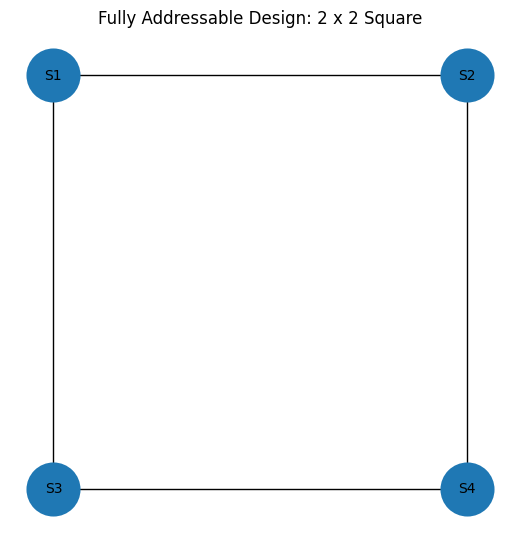

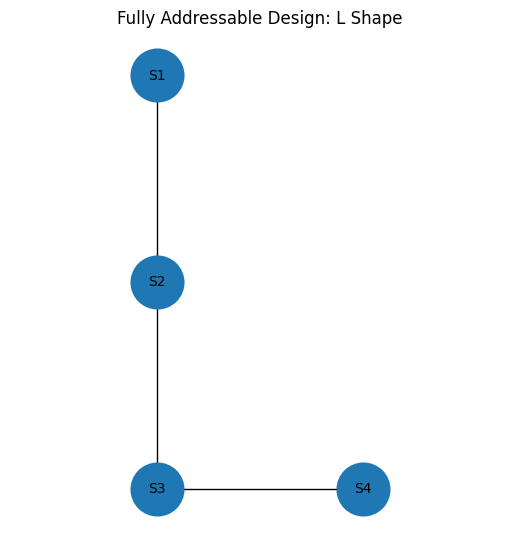

In [2]:
# ============================================================
# Step 2: Building a fully addressable baseline design
# ============================================================

# What I am doing:
# In this cell, I create a fully addressable design for each target shape.
# This means every grid position gets a unique building block species, and
# every required connection gets its own unique complementary interaction pair.
# This gives a high-complexity baseline that I can compare against later.

import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


def get_direction(pos_a, pos_b):
    """
    Return the grid direction from position A to position B.
    """
    row_a, col_a = pos_a
    row_b, col_b = pos_b

    if row_b == row_a - 1 and col_b == col_a:
        return "up"
    if row_b == row_a + 1 and col_b == col_a:
        return "down"
    if row_b == row_a and col_b == col_a - 1:
        return "left"
    if row_b == row_a and col_b == col_a + 1:
        return "right"

    return "not_adjacent"


def opposite_direction(direction):
    """
    Return the opposite side of a grid based building block.
    """
    opposites = {
        "up": "down",
        "down": "up",
        "left": "right",
        "right": "left"
    }

    return opposites[direction]


def create_fully_addressable_design(graph, shape_name):
    """
    Create a fully addressable design for a target shape graph.

    Each node receives a unique building block species.
    Each edge receives a unique complementary color pair.
    """
    sorted_nodes = sorted(list(graph.nodes()))

    species_map = {}
    for index, node in enumerate(sorted_nodes, start=1):
        species_map[node] = f"S{index}"

    patch_data = {}

    for node in sorted_nodes:
        patch_data[node] = {
            "position": node,
            "species": species_map[node],
            "up_patch": None,
            "down_patch": None,
            "left_patch": None,
            "right_patch": None
        }

    interaction_rows = []

    for edge_index, (node_a, node_b) in enumerate(graph.edges(), start=1):
        direction_a_to_b = get_direction(node_a, node_b)
        direction_b_to_a = opposite_direction(direction_a_to_b)

        color_a = f"C{edge_index}+"
        color_b = f"C{edge_index}-"

        patch_data[node_a][f"{direction_a_to_b}_patch"] = color_a
        patch_data[node_b][f"{direction_b_to_a}_patch"] = color_b

        interaction_rows.append({
            "shape": shape_name,
            "connection": f"{node_a} ↔ {node_b}",
            "species_a": species_map[node_a],
            "patch_on_a": direction_a_to_b,
            "color_on_a": color_a,
            "species_b": species_map[node_b],
            "patch_on_b": direction_b_to_a,
            "color_on_b": color_b,
            "compatible_pair": f"{color_a} binds {color_b}"
        })

    species_table = pd.DataFrame(list(patch_data.values()))
    interaction_table = pd.DataFrame(interaction_rows)

    summary_table = pd.DataFrame([{
        "shape": shape_name,
        "design_type": "Fully addressable",
        "number_of_building_blocks_in_shape": graph.number_of_nodes(),
        "number_of_species_Ns": len(set(species_map.values())),
        "number_of_required_interactions": graph.number_of_edges(),
        "number_of_patch_colors_Nc": graph.number_of_edges() * 2
    }])

    return species_table, interaction_table, summary_table, species_map


def plot_species_design(graph, species_map, title):
    """
    Plot the target shape with each node labeled by its assigned species.
    """
    layout = {node: (node[1], -node[0]) for node in graph.nodes()}
    labels = {node: species_map[node] for node in graph.nodes()}

    plt.figure(figsize=(5, 5))
    nx.draw(
        graph,
        pos=layout,
        labels=labels,
        with_labels=True,
        node_size=1400,
        font_size=10,
        linewidths=1.5
    )

    plt.title(title)
    plt.axis("equal")
    plt.show()


# Fully addressable design for the 2 x 2 square
square_species_table, square_interaction_table, square_design_summary, square_species_map = create_fully_addressable_design(
    square_graph,
    "2 x 2 square"
)

# Fully addressable design for the L shape
l_species_table, l_interaction_table, l_design_summary, l_species_map = create_fully_addressable_design(
    l_shape_graph,
    "L shape"
)

# Display summary comparison
fully_addressable_summary = pd.concat(
    [square_design_summary, l_design_summary],
    ignore_index=True
)

display(fully_addressable_summary)

print("Fully addressable species table for 2 x 2 square:")
display(square_species_table)

print("Fully addressable interaction table for 2 x 2 square:")
display(square_interaction_table)

plot_species_design(
    square_graph,
    square_species_map,
    "Fully Addressable Design: 2 x 2 Square"
)

plot_species_design(
    l_shape_graph,
    l_species_map,
    "Fully Addressable Design: L Shape"
)

## Step 3: Creating a Reduced Complexity Design

The fully addressable design is useful as a baseline, but it is usually not the most efficient way to describe a self assembled structure.

In this step, I create a simplified reduced complexity design. The main idea is to reuse the same building block species when two positions in the target shape have the same local connection pattern. For example, if two positions both behave like corner pieces, they may not need to be treated as completely different species.

This is not the same as the full SAT based inverse design method used in the paper. However, it captures one of the important design ideas: reducing the number of unique components while still keeping enough structural information to describe the target shape.

For this first version, I group positions based on their local neighborhood pattern. I also allow rotated versions of the same pattern to be treated as the same species. This makes the model closer to the idea of reusable building blocks.

,shape,design_type,number_of_building_blocks_in_shape,number_of_species_Ns,number_of_required_interactions
0,2 x 2 square,Reduced local-pattern design,4,1,4
1,L shape,Reduced local-pattern design,4,3,3


Reduced-complexity design table for 2 x 2 square:


,shape,position,local_connection_pattern_up_right_down_left,rotation_invariant_pattern,assigned_reduced_species
0,2 x 2 square,"(0, 0)","(0, 1, 1, 0)","(0, 0, 1, 1)",R1
1,2 x 2 square,"(0, 1)","(0, 0, 1, 1)","(0, 0, 1, 1)",R1
2,2 x 2 square,"(1, 0)","(1, 1, 0, 0)","(0, 0, 1, 1)",R1
3,2 x 2 square,"(1, 1)","(1, 0, 0, 1)","(0, 0, 1, 1)",R1


Reduced-complexity design table for L shape:


,shape,position,local_connection_pattern_up_right_down_left,rotation_invariant_pattern,assigned_reduced_species
0,L shape,"(0, 0)","(0, 0, 1, 0)","(0, 0, 0, 1)",R1
1,L shape,"(1, 0)","(1, 0, 1, 0)","(0, 1, 0, 1)",R3
2,L shape,"(2, 0)","(1, 1, 0, 0)","(0, 0, 1, 1)",R2
3,L shape,"(2, 1)","(0, 0, 0, 1)","(0, 0, 0, 1)",R1


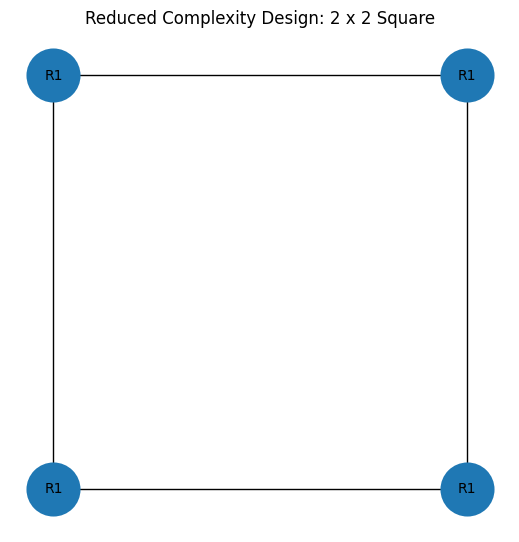

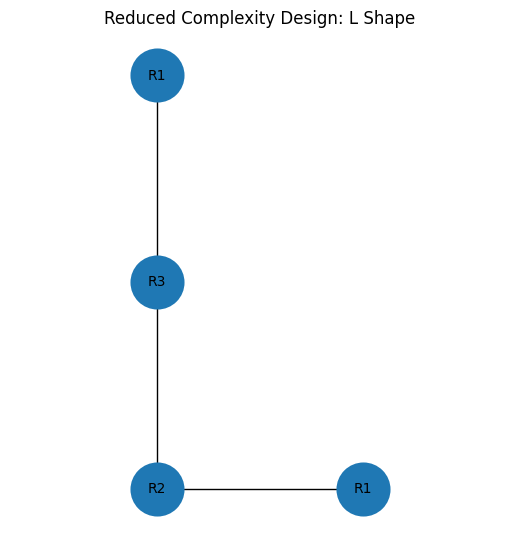

In [3]:
# ============================================================
# Step 3: Creating a reduced complexity design
# ============================================================

# What I am doing:
# In this cell, I create a simplified reduced-complexity design.
# Instead of giving every position a unique species, I group positions
# that have the same local connection pattern. Rotated versions of the
# same pattern are treated as reusable versions of the same building block.

import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


DIRECTIONS = ["up", "right", "down", "left"]

DIRECTION_VECTORS = {
    "up": (-1, 0),
    "right": (0, 1),
    "down": (1, 0),
    "left": (0, -1)
}


def local_connection_pattern(graph, node):
    """
    Return a binary pattern showing which sides of a node are connected.

    The pattern follows this order:
    up, right, down, left

    Example:
    (1, 1, 0, 0) means the block connects upward and to the right.
    """
    row, col = node
    neighbors = set(graph.neighbors(node))

    pattern = []

    for direction in DIRECTIONS:
        drow, dcol = DIRECTION_VECTORS[direction]
        neighbor = (row + drow, col + dcol)

        if neighbor in neighbors:
            pattern.append(1)
        else:
            pattern.append(0)

    return tuple(pattern)


def rotate_pattern(pattern, steps):
    """
    Rotate a local connection pattern.

    Since the pattern order is up, right, down, left,
    rotating by one step corresponds to a 90-degree rotation.
    """
    steps = steps % 4
    return tuple(pattern[-steps:] + pattern[:-steps])


def canonical_pattern(pattern):
    """
    Return the simplest rotation-equivalent version of a pattern.

    This allows corner pieces, line pieces, and other repeated local
    structures to be grouped even if they appear in different orientations.
    """
    rotations = [rotate_pattern(list(pattern), steps) for steps in range(4)]
    return min(rotations)


def create_reduced_complexity_design(graph, shape_name):
    """
    Create a reduced-complexity design by grouping positions with the same
    rotation-invariant local connection pattern.
    """
    sorted_nodes = sorted(list(graph.nodes()))

    node_patterns = {}
    canonical_patterns = {}

    for node in sorted_nodes:
        pattern = local_connection_pattern(graph, node)
        canonical = canonical_pattern(pattern)

        node_patterns[node] = pattern
        canonical_patterns[node] = canonical

    unique_patterns = sorted(set(canonical_patterns.values()))

    pattern_to_species = {}
    for index, pattern in enumerate(unique_patterns, start=1):
        pattern_to_species[pattern] = f"R{index}"

    species_map = {}
    design_rows = []

    for node in sorted_nodes:
        species = pattern_to_species[canonical_patterns[node]]
        species_map[node] = species

        design_rows.append({
            "shape": shape_name,
            "position": node,
            "local_connection_pattern_up_right_down_left": node_patterns[node],
            "rotation_invariant_pattern": canonical_patterns[node],
            "assigned_reduced_species": species
        })

    design_table = pd.DataFrame(design_rows)

    summary_table = pd.DataFrame([{
        "shape": shape_name,
        "design_type": "Reduced local-pattern design",
        "number_of_building_blocks_in_shape": graph.number_of_nodes(),
        "number_of_species_Ns": len(set(species_map.values())),
        "number_of_required_interactions": graph.number_of_edges()
    }])

    return design_table, summary_table, species_map


def plot_reduced_species_design(graph, species_map, title):
    """
    Plot the target shape with reduced species labels.
    """
    layout = {node: (node[1], -node[0]) for node in graph.nodes()}
    labels = {node: species_map[node] for node in graph.nodes()}

    plt.figure(figsize=(5, 5))
    nx.draw(
        graph,
        pos=layout,
        labels=labels,
        with_labels=True,
        node_size=1400,
        font_size=10,
        linewidths=1.5
    )

    plt.title(title)
    plt.axis("equal")
    plt.show()


# Reduced-complexity design for the 2 x 2 square
square_reduced_table, square_reduced_summary, square_reduced_species_map = create_reduced_complexity_design(
    square_graph,
    "2 x 2 square"
)

# Reduced-complexity design for the L shape
l_reduced_table, l_reduced_summary, l_reduced_species_map = create_reduced_complexity_design(
    l_shape_graph,
    "L shape"
)

# Display reduced design summaries
reduced_summary = pd.concat(
    [square_reduced_summary, l_reduced_summary],
    ignore_index=True
)

display(reduced_summary)

print("Reduced-complexity design table for 2 x 2 square:")
display(square_reduced_table)

print("Reduced-complexity design table for L shape:")
display(l_reduced_table)

plot_reduced_species_design(
    square_graph,
    square_reduced_species_map,
    "Reduced Complexity Design: 2 x 2 Square"
)

plot_reduced_species_design(
    l_shape_graph,
    l_reduced_species_map,
    "Reduced Complexity Design: L Shape"
)

## Step 4: Comparing Fully Addressable and Reduced Complexity Designs

At this point, I have created two different design representations for the same target shapes.

The first representation is the fully addressable design, where every position in the structure is assigned a unique building block species. This gives the most specific design, but it also creates the highest component complexity.

The second representation is the reduced local-pattern design, where positions with similar local connection patterns are grouped into reusable species. This reduces the number of distinct building block types needed to describe the same shape.

In this step, I compare both designs side by side. The goal is to measure how much the number of required species decreases when reusable building block types are allowed.

In [4]:
# ============================================================
# Step 4: Comparing fully addressable and reduced designs
# ============================================================

# What I am doing:
# In this cell, I compare the fully addressable design against the
# reduced local-pattern design. This helps quantify how much complexity
# is reduced when building block species are reused.

import pandas as pd
import matplotlib.pyplot as plt


def compare_design_complexity(fully_addressable_summary, reduced_summary):
    """
    Compare fully addressable and reduced-complexity designs.

    The comparison focuses on the number of distinct species needed
    to describe each target shape.
    """
    full = fully_addressable_summary[
        [
            "shape",
            "number_of_building_blocks_in_shape",
            "number_of_species_Ns",
            "number_of_required_interactions",
            "number_of_patch_colors_Nc"
        ]
    ].copy()

    full = full.rename(columns={
        "number_of_species_Ns": "fully_addressable_species",
        "number_of_patch_colors_Nc": "fully_addressable_patch_colors"
    })

    reduced = reduced_summary[
        [
            "shape",
            "number_of_species_Ns"
        ]
    ].copy()

    reduced = reduced.rename(columns={
        "number_of_species_Ns": "reduced_design_species"
    })

    comparison = pd.merge(full, reduced, on="shape")

    comparison["species_saved"] = (
        comparison["fully_addressable_species"] -
        comparison["reduced_design_species"]
    )

    comparison["species_reduction_percent"] = (
        comparison["species_saved"] /
        comparison["fully_addressable_species"] * 100
    ).round(2)

    return comparison


complexity_comparison = compare_design_complexity(
    fully_addressable_summary,
    reduced_summary
)

display(complexity_comparison)

,shape,number_of_building_blocks_in_shape,fully_addressable_species,number_of_required_interactions,fully_addressable_patch_colors,reduced_design_species,species_saved,species_reduction_percent
0,2 x 2 square,4,4,4,8,1,3,75.0
1,L shape,4,4,3,6,3,1,25.0


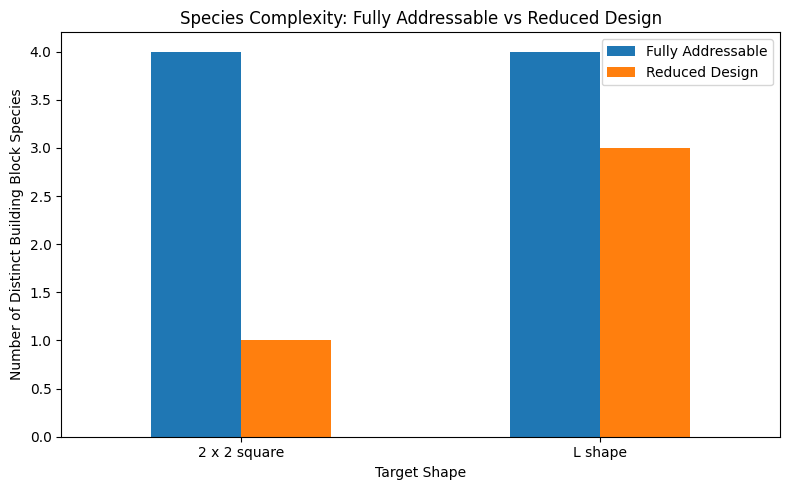

In [5]:
# ============================================================
# Step 4 continued: Visualizing the complexity comparison
# ============================================================

# What I am doing:
# In this cell, I create a simple bar chart comparing the number of
# species used in the fully addressable and reduced-complexity designs.

plot_data = complexity_comparison[
    [
        "shape",
        "fully_addressable_species",
        "reduced_design_species"
    ]
].set_index("shape")

ax = plot_data.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Species Complexity: Fully Addressable vs Reduced Design")
plt.xlabel("Target Shape")
plt.ylabel("Number of Distinct Building Block Species")
plt.xticks(rotation=0)
plt.legend(["Fully Addressable", "Reduced Design"])
plt.tight_layout()
plt.show()

## Step 5: Interpreting the Complexity Reduction

The comparison shows that the same target shape can be described using different levels of design complexity.

In the fully addressable design, every position in the target structure is treated as a unique building block. This gives a very direct and specific design, but it also requires more distinct species. In the reduced local-pattern design, some positions are grouped together when they share the same local connection pattern. This allows the same target structure to be described with fewer reusable building block types.

For the 2 x 2 square, the reduction is especially clear because all four positions behave like rotated versions of the same corner-like building block. In this simplified model, that allows the shape to be represented with one reusable species instead of four unique species.

The L shape is more restrictive because not all positions have the same local role. Some positions behave like endpoints, one behaves like a corner, and one behaves like a connector. Because of this, the reduced design still needs more than one species, but it is still less complex than the fully addressable version.

This result supports the main design idea explored in the paper: a target structure does not always require every building block to be unique. In some cases, reusable building block types can reduce design complexity while still preserving the structural information needed to describe the target assembly.

At this stage, my model is still simplified. It does not prove that the reduced design will physically assemble correctly, but it gives a useful first approximation of how component reuse can reduce design complexity.

## Step 6: Testing Whether the Reduced Design Is Ambiguous

Reducing the number of building block species is useful only if the reduced design still describes the intended target structure clearly.

In this step, I test the reduced local-pattern design using a simple stochastic assembly model. The goal is not to reproduce the full simulation pipeline from the paper, but to check whether the simplified reduced design can still guide assembly toward the target shape or whether it allows ambiguous growth.

This is an important step because a design with fewer species may look efficient on paper, but it may also become too general. If the same reusable species can connect in too many ways, the system may form larger or incorrect structures instead of stopping at the intended target.

,shape,outcome,trial_count,percent_of_trials
0,2 x 2 square,overgrowth_or_ambiguous,100,100.0
1,L shape,overgrowth_or_ambiguous,100,100.0


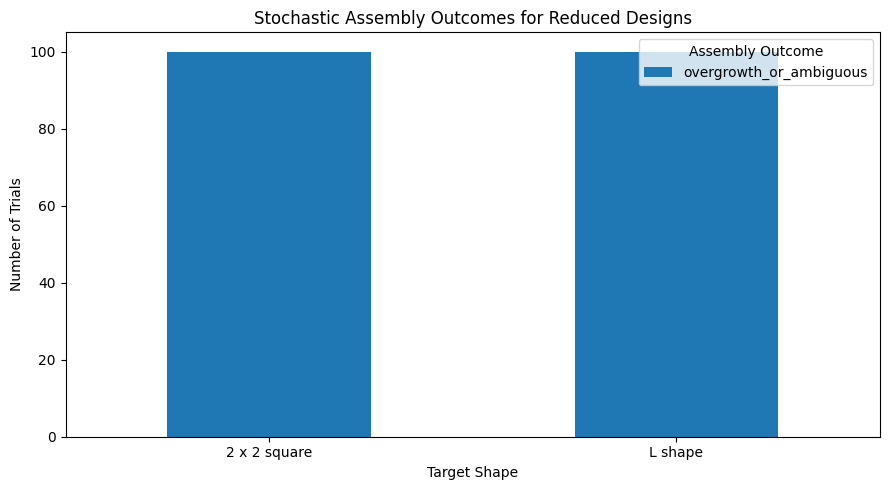

In [6]:
# ============================================================
# Step 6: Testing whether the reduced design is ambiguous
# ============================================================

# What I am doing:
# In this cell, I create a simple stochastic assembly test for the reduced
# design. The model starts from one building block and repeatedly adds
# compatible neighboring blocks based on the reduced species interaction rules.
# This helps test whether a reduced design still forms the intended target
# shape or whether it allows ambiguous or unbounded growth.

import random
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


DIRECTION_VECTORS = {
    "up": (-1, 0),
    "right": (0, 1),
    "down": (1, 0),
    "left": (0, -1)
}

OPPOSITE_DIRECTIONS = {
    "up": "down",
    "down": "up",
    "left": "right",
    "right": "left"
}


def direction_between(pos_a, pos_b):
    """
    Return the grid direction from position A to directly adjacent position B.
    """
    row_a, col_a = pos_a
    row_b, col_b = pos_b

    if row_b == row_a - 1 and col_b == col_a:
        return "up"
    if row_b == row_a + 1 and col_b == col_a:
        return "down"
    if row_b == row_a and col_b == col_a - 1:
        return "left"
    if row_b == row_a and col_b == col_a + 1:
        return "right"

    return None


def normalize_coordinates(coordinates):
    """
    Shift coordinates so the top-left occupied cell becomes (0, 0).
    """
    min_row = min(row for row, col in coordinates)
    min_col = min(col for row, col in coordinates)

    normalized = sorted([
        (row - min_row, col - min_col)
        for row, col in coordinates
    ])

    return tuple(normalized)


def rotate_coordinates_90(coordinates):
    """
    Rotate a set of coordinates by 90 degrees.
    """
    return [(-col, row) for row, col in coordinates]


def reflect_coordinates(coordinates):
    """
    Reflect a set of coordinates horizontally.
    """
    return [(row, -col) for row, col in coordinates]


def equivalent_shape_signatures(coordinates):
    """
    Generate normalized signatures for rotations and reflections of a shape.

    This allows the target shape to be recognized even if it appears rotated
    or reflected during the simple assembly process.
    """
    coordinates = list(coordinates)
    signatures = []

    current = coordinates

    for _ in range(4):
        signatures.append(normalize_coordinates(current))
        signatures.append(normalize_coordinates(reflect_coordinates(current)))
        current = rotate_coordinates_90(current)

    return set(signatures)


def create_species_interaction_rules(graph, species_map):
    """
    Create species-level directional interaction rules from a target graph.

    A rule has the form:
    species A can connect in a given direction to species B.
    """
    rules = set()

    for node_a, node_b in graph.edges():
        direction_a_to_b = direction_between(node_a, node_b)
        direction_b_to_a = OPPOSITE_DIRECTIONS[direction_a_to_b]

        species_a = species_map[node_a]
        species_b = species_map[node_b]

        rules.add((species_a, direction_a_to_b, species_b))
        rules.add((species_b, direction_b_to_a, species_a))

    return rules


def candidate_is_consistent(new_position, new_species, assembly, rules):
    """
    Check whether a proposed new block is compatible with all occupied neighbors.
    """
    for direction, vector in DIRECTION_VECTORS.items():
        neighbor_position = (
            new_position[0] + vector[0],
            new_position[1] + vector[1]
        )

        if neighbor_position in assembly:
            neighbor_species = assembly[neighbor_position]
            opposite_direction = OPPOSITE_DIRECTIONS[direction]

            if (new_species, direction, neighbor_species) not in rules:
                return False

            if (neighbor_species, opposite_direction, new_species) not in rules:
                return False

    return True


def stochastic_assembly_trial(graph, species_map, max_size_multiplier=3, seed=None):
    """
    Run one simple stochastic assembly trial.

    The assembly starts from one species and grows by randomly adding compatible
    neighboring species. If the assembly grows beyond the intended target size,
    it is treated as overgrowth.
    """
    if seed is not None:
        random.seed(seed)

    target_size = graph.number_of_nodes()
    max_size = target_size * max_size_multiplier

    rules = create_species_interaction_rules(graph, species_map)
    target_signature_set = equivalent_shape_signatures(graph.nodes())

    possible_seed_species = sorted(set(species_map.values()))
    starting_species = random.choice(possible_seed_species)

    assembly = {
        (0, 0): starting_species
    }

    while len(assembly) < max_size:
        candidates = []

        for occupied_position, occupied_species in assembly.items():
            for direction, vector in DIRECTION_VECTORS.items():
                new_position = (
                    occupied_position[0] + vector[0],
                    occupied_position[1] + vector[1]
                )

                if new_position in assembly:
                    continue

                for rule_species_a, rule_direction, rule_species_b in rules:
                    if rule_species_a == occupied_species and rule_direction == direction:
                        if candidate_is_consistent(
                            new_position,
                            rule_species_b,
                            assembly,
                            rules
                        ):
                            candidates.append((new_position, rule_species_b))

        if not candidates:
            break

        new_position, new_species = random.choice(candidates)
        assembly[new_position] = new_species

    final_coordinates = list(assembly.keys())
    final_signature = normalize_coordinates(final_coordinates)

    if len(assembly) > target_size:
        outcome = "overgrowth_or_ambiguous"
    elif final_signature in target_signature_set and len(assembly) == target_size:
        outcome = "target_shape"
    elif len(assembly) < target_size:
        outcome = "incomplete"
    else:
        outcome = "off_target_shape"

    return {
        "outcome": outcome,
        "assembly": assembly,
        "rules": rules
    }


def run_stochastic_assembly_experiment(graph, species_map, shape_name, trials=100):
    """
    Run multiple stochastic assembly trials and summarize the outcomes.
    """
    results = []

    for trial in range(trials):
        result = stochastic_assembly_trial(
            graph,
            species_map,
            seed=trial
        )

        results.append({
            "shape": shape_name,
            "trial": trial + 1,
            "outcome": result["outcome"],
            "final_size": len(result["assembly"])
        })

    results_table = pd.DataFrame(results)

    summary = (
        results_table
        .groupby(["shape", "outcome"])
        .size()
        .reset_index(name="trial_count")
    )

    summary["percent_of_trials"] = (
        summary["trial_count"] / trials * 100
    ).round(2)

    return results_table, summary


def plot_assembly_outcomes(summary_table, title):
    """
    Plot the stochastic assembly outcome distribution.
    """
    pivot_table = summary_table.pivot(
        index="shape",
        columns="outcome",
        values="trial_count"
    ).fillna(0)

    ax = pivot_table.plot(
        kind="bar",
        figsize=(9, 5)
    )

    plt.title(title)
    plt.xlabel("Target Shape")
    plt.ylabel("Number of Trials")
    plt.xticks(rotation=0)
    plt.legend(title="Assembly Outcome")
    plt.tight_layout()
    plt.show()


# Run stochastic assembly tests for the reduced-complexity designs
square_trials, square_assembly_summary = run_stochastic_assembly_experiment(
    square_graph,
    square_reduced_species_map,
    "2 x 2 square",
    trials=100
)

l_trials, l_assembly_summary = run_stochastic_assembly_experiment(
    l_shape_graph,
    l_reduced_species_map,
    "L shape",
    trials=100
)

assembly_summary = pd.concat(
    [square_assembly_summary, l_assembly_summary],
    ignore_index=True
)

display(assembly_summary)

plot_assembly_outcomes(
    assembly_summary,
    "Stochastic Assembly Outcomes for Reduced Designs"
)

## Step 7: Visualizing Example Assembly Outcomes

The stochastic assembly test gives a summary of whether a reduced design reaches the target shape, stops early, forms an off target shape, or grows beyond the intended structure.

However, the summary table alone does not fully explain what is happening. In this step, I visualize example assemblies from individual trials. This helps make the result easier to interpret and gives a more concrete view of why reduced complexity designs can sometimes become ambiguous.

This step is especially important because minimal designs are not automatically better just because they use fewer species. A useful design must balance lower component complexity with enough specificity to avoid incorrect or unbounded growth.

In [7]:
# ============================================================
# Step 7: Visualizing example stochastic assembly outcomes
# ============================================================

# What I am doing:
# In this cell, I visualize individual stochastic assembly outcomes.
# This makes the ambiguity test easier to understand by showing what
# successful, incomplete, off-target, or overgrown assemblies look like.

import matplotlib.pyplot as plt
import networkx as nx
import pandas as pd


def assembly_to_graph(assembly):
    """
    Convert an assembled set of occupied positions into a graph.
    """
    graph = nx.Graph()

    for position, species in assembly.items():
        graph.add_node(position, species=species)

    position_set = set(assembly.keys())

    for row, col in position_set:
        for direction, vector in DIRECTION_VECTORS.items():
            neighbor = (row + vector[0], col + vector[1])

            if neighbor in position_set:
                graph.add_edge((row, col), neighbor)

    return graph


def plot_assembly(assembly, title):
    """
    Plot a stochastic assembly result with species labels.
    """
    graph = assembly_to_graph(assembly)

    layout = {
        node: (node[1], -node[0])
        for node in graph.nodes()
    }

    labels = {
        node: assembly[node]
        for node in graph.nodes()
    }

    plt.figure(figsize=(5, 5))
    nx.draw(
        graph,
        pos=layout,
        labels=labels,
        with_labels=True,
        node_size=1400,
        font_size=10,
        linewidths=1.5
    )

    plt.title(title)
    plt.axis("equal")
    plt.show()


def find_example_trial(graph, species_map, desired_outcome, max_attempts=500):
    """
    Search for one stochastic assembly trial with the desired outcome.
    """
    for seed in range(max_attempts):
        result = stochastic_assembly_trial(
            graph,
            species_map,
            seed=seed
        )

        if result["outcome"] == desired_outcome:
            return result, seed

    return None, None


def show_available_outcomes(graph, species_map, shape_name, max_attempts=200):
    """
    Show which outcomes appear across multiple stochastic trials.
    """
    observed = []

    for seed in range(max_attempts):
        result = stochastic_assembly_trial(
            graph,
            species_map,
            seed=seed
        )

        observed.append(result["outcome"])

    observed_table = (
        pd.Series(observed)
        .value_counts()
        .reset_index()
    )

    observed_table.columns = ["outcome", "count"]

    print(f"Observed outcomes for {shape_name}:")
    display(observed_table)

    return observed_table


# Check which outcomes appear for each reduced design
square_observed_outcomes = show_available_outcomes(
    square_graph,
    square_reduced_species_map,
    "2 x 2 square"
)

l_shape_observed_outcomes = show_available_outcomes(
    l_shape_graph,
    l_reduced_species_map,
    "L shape"
)

Observed outcomes for 2 x 2 square:


,outcome,count
0,overgrowth_or_ambiguous,200


Observed outcomes for L shape:


,outcome,count
0,overgrowth_or_ambiguous,200


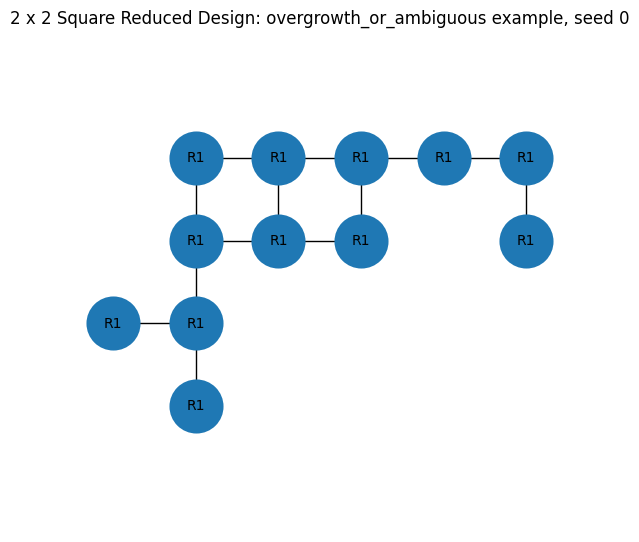

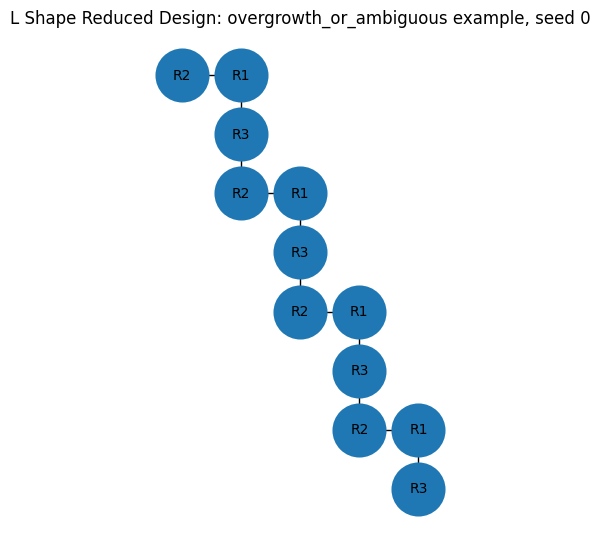

In [8]:
# ============================================================
# Step 7 continued: Plotting selected assembly examples
# ============================================================

# What I am doing:
# In this cell, I plot one example of each available outcome for the
# reduced-complexity designs. This helps visually explain whether the
# reduced design is specific enough or too ambiguous.

outcomes_to_check = [
    "target_shape",
    "incomplete",
    "off_target_shape",
    "overgrowth_or_ambiguous"
]

for outcome in outcomes_to_check:
    result, seed = find_example_trial(
        square_graph,
        square_reduced_species_map,
        desired_outcome=outcome
    )

    if result is not None:
        plot_assembly(
            result["assembly"],
            f"2 x 2 Square Reduced Design: {outcome} example, seed {seed}"
        )

for outcome in outcomes_to_check:
    result, seed = find_example_trial(
        l_shape_graph,
        l_reduced_species_map,
        desired_outcome=outcome
    )

    if result is not None:
        plot_assembly(
            result["assembly"],
            f"L Shape Reduced Design: {outcome} example, seed {seed}"
        )

## Step 8: Creating a Simple Design Quality Score

After testing the reduced complexity designs, I want to summarize the tradeoff between efficiency and reliability.

A reduced design is not automatically better just because it uses fewer species. If the design becomes too general, it may allow overgrowth, incomplete assembly, or off target structures. A useful reduced design should lower component complexity while still producing the intended target shape at a reasonable rate.

To make this tradeoff easier to compare, I define a simple design quality score. This score combines two ideas: how much the number of species was reduced compared to the fully addressable design, and how often the stochastic assembly test produced the correct target shape.

This score is not meant to be a formal physical metric. It is a simplified analysis tool for this notebook that helps compare reduced designs in a clear and interpretable way.

In [9]:
# ============================================================
# Step 8: Creating a simple design quality score
# ============================================================

# What I am doing:
# In this cell, I combine the complexity comparison with the stochastic
# assembly results. This creates a simple score that rewards designs that
# both reduce the number of species and still assemble into the target shape.

import pandas as pd
import matplotlib.pyplot as plt


def build_design_quality_table(complexity_comparison, assembly_summary):
    """
    Create a simple design quality table.

    The score combines:
    1. Species reduction compared to the fully addressable design
    2. Target shape success rate from the stochastic assembly experiment
    """
    outcome_pivot = assembly_summary.pivot(
        index="shape",
        columns="outcome",
        values="percent_of_trials"
    ).fillna(0).reset_index()

    required_outcomes = [
        "target_shape",
        "incomplete",
        "off_target_shape",
        "overgrowth_or_ambiguous"
    ]

    for outcome in required_outcomes:
        if outcome not in outcome_pivot.columns:
            outcome_pivot[outcome] = 0

    quality_table = pd.merge(
        complexity_comparison,
        outcome_pivot,
        on="shape",
        how="left"
    )

    quality_table["complexity_reduction_fraction"] = (
        quality_table["species_reduction_percent"] / 100
    )

    quality_table["assembly_success_fraction"] = (
        quality_table["target_shape"] / 100
    )

    quality_table["simple_design_quality_score"] = (
        quality_table["complexity_reduction_fraction"] *
        quality_table["assembly_success_fraction"] *
        100
    ).round(2)

    final_columns = [
        "shape",
        "fully_addressable_species",
        "reduced_design_species",
        "species_reduction_percent",
        "target_shape",
        "incomplete",
        "off_target_shape",
        "overgrowth_or_ambiguous",
        "simple_design_quality_score"
    ]

    return quality_table[final_columns]


design_quality_table = build_design_quality_table(
    complexity_comparison,
    assembly_summary
)

display(design_quality_table)

,shape,fully_addressable_species,reduced_design_species,species_reduction_percent,target_shape,incomplete,off_target_shape,overgrowth_or_ambiguous,simple_design_quality_score
0,2 x 2 square,4,1,75.0,0,0,0,100.0,0.0
1,L shape,4,3,25.0,0,0,0,100.0,0.0


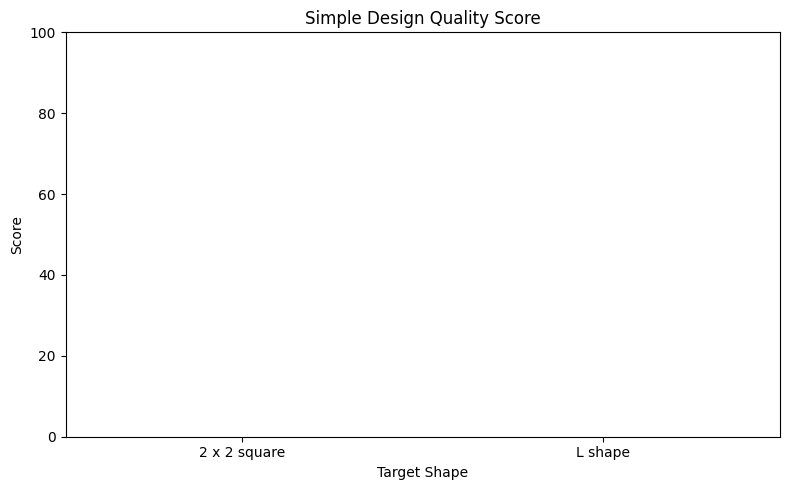

In [10]:
# ============================================================
# Step 8 continued: Visualizing the design quality score
# ============================================================

# What I am doing:
# In this cell, I visualize the simple design quality score for each shape.
# This makes it easier to see which reduced designs balance simplicity
# and assembly reliability better.

plt.figure(figsize=(8, 5))

plt.bar(
    design_quality_table["shape"],
    design_quality_table["simple_design_quality_score"]
)

plt.title("Simple Design Quality Score")
plt.xlabel("Target Shape")
plt.ylabel("Score")
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

In [11]:
# ============================================================
# Step 8 diagnostic: Checking why the design quality score is blank
# ============================================================

# What I am doing:
# The chart looks blank because the score may be zero.
# This cell displays the values behind the chart so I can confirm
# whether the issue is a plotting error or a real modeling result.

print("Assembly summary:")
display(assembly_summary)

print("Complexity comparison:")
display(complexity_comparison)

print("Design quality table:")
display(design_quality_table)

Assembly summary:


,shape,outcome,trial_count,percent_of_trials
0,2 x 2 square,overgrowth_or_ambiguous,100,100.0
1,L shape,overgrowth_or_ambiguous,100,100.0


Complexity comparison:


,shape,number_of_building_blocks_in_shape,fully_addressable_species,number_of_required_interactions,fully_addressable_patch_colors,reduced_design_species,species_saved,species_reduction_percent
0,2 x 2 square,4,4,4,8,1,3,75.0
1,L shape,4,4,3,6,3,1,25.0


Design quality table:


,shape,fully_addressable_species,reduced_design_species,species_reduction_percent,target_shape,incomplete,off_target_shape,overgrowth_or_ambiguous,simple_design_quality_score
0,2 x 2 square,4,1,75.0,0,0,0,100.0,0.0
1,L shape,4,3,25.0,0,0,0,100.0,0.0


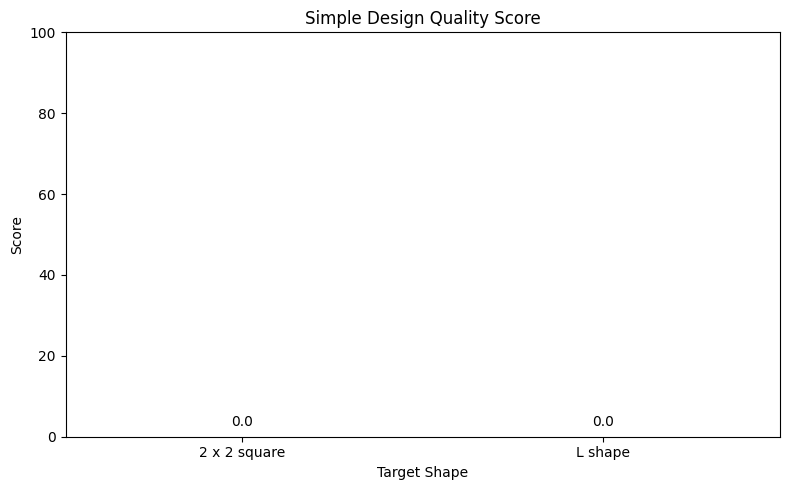

In [12]:
# ============================================================
# Step 8 revised: Visualizing the design quality score clearly
# ============================================================

# What I am doing:
# In the earlier plot, a score of zero looked like an empty chart.
# This revised version annotates the score values directly so that
# zero scores are still visible and interpretable.

plt.figure(figsize=(8, 5))

bars = plt.bar(
    design_quality_table["shape"],
    design_quality_table["simple_design_quality_score"]
)

plt.title("Simple Design Quality Score")
plt.xlabel("Target Shape")
plt.ylabel("Score")
plt.ylim(0, 100)

for bar, score in zip(bars, design_quality_table["simple_design_quality_score"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        score + 2,
        f"{score:.1f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.show()

### Interpretation of the Zero Score

The zero score does not mean the notebook failed. It means the first reduced design is too ambiguous under the simple stochastic assembly test.

The reduced design saves species, but it does not reliably produce the intended target shape. This shows an important tradeoff: reducing the number of building block types can make a design more efficient, but it can also remove too much specificity.

This is why the original paper does not rely only on component reduction. Candidate designs must also be tested for whether they assemble correctly and avoid competing structures. In this simplified notebook, the zero score is useful because it shows that a naive reduced design is not enough.

## Step 9: Adding Orientation Awareness to the Reduced Design

The first reduced design grouped building blocks by local connection pattern, but it treated the species labels too loosely during assembly. As a result, a reusable species could sometimes connect in too many ways, which created ambiguous or off target growth.

In the original paper, building blocks are not only defined by species. Their patches also have directions, colors, orientations, and compatibility rules. This is important because a reduced design still needs enough local information to guide the assembly process.

In this step, I improve the simplified model by adding orientation awareness. A reusable building block species can still appear in different rotated forms, but the model now checks whether the rotated patch pattern is compatible with the neighboring blocks.

I also use a bounded inventory based on the number of building blocks in the target shape. This keeps the model focused on whether the reduced rule can form the intended finite structure rather than allowing unlimited growth.

This is still a simplified model, but it is closer to the design logic of the paper because it tests whether component reuse can work when local geometric constraints are included.

In [14]:
# ============================================================
# Step 9: Orientation-aware reduced assembly model
# ============================================================

# What I am doing:
# In the first reduced model, species were reused too freely.
# Here, I improve the model by giving each reusable species a local patch pattern
# and allowing that pattern to rotate. During stochastic assembly, a block can
# only attach if its rotated patch pattern is compatible with neighboring blocks.

import random
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx


DIRECTIONS_ORDERED = ["up", "right", "down", "left"]

DIRECTION_VECTORS_ORIENTED = {
    "up": (-1, 0),
    "right": (0, 1),
    "down": (1, 0),
    "left": (0, -1)
}

OPPOSITE_DIRECTIONS_ORIENTED = {
    "up": "down",
    "down": "up",
    "left": "right",
    "right": "left"
}


def rotate_pattern_for_orientation(pattern, rotation_steps):
    """
    Rotate a patch pattern by 90-degree steps.

    Pattern order:
    up, right, down, left
    """
    pattern = list(pattern)
    rotation_steps = rotation_steps % 4

    return tuple(pattern[-rotation_steps:] + pattern[:-rotation_steps])


def pattern_has_patch(pattern, direction):
    """
    Check whether a rotated patch pattern has a patch in a given direction.
    """
    direction_index = DIRECTIONS_ORDERED.index(direction)

    return pattern[direction_index] == 1


def create_orientation_aware_species_model(graph, shape_name):
    """
    Create species definitions for the orientation-aware reduced model.

    Positions with the same rotation-invariant local pattern are assigned
    to the same species. Each species stores one base patch pattern that
    can be rotated during assembly.
    """
    sorted_nodes = sorted(list(graph.nodes()))

    node_to_original_pattern = {}
    node_to_canonical_pattern = {}

    for node in sorted_nodes:
        pattern = local_connection_pattern(graph, node)
        canonical = canonical_pattern(pattern)

        node_to_original_pattern[node] = pattern
        node_to_canonical_pattern[node] = canonical

    unique_canonical_patterns = sorted(set(node_to_canonical_pattern.values()))

    pattern_to_species = {}
    for index, pattern in enumerate(unique_canonical_patterns, start=1):
        pattern_to_species[pattern] = f"OR{index}"

    node_to_species = {}
    species_definitions = {}

    for pattern, species in pattern_to_species.items():
        species_definitions[species] = pattern

    rows = []

    for node in sorted_nodes:
        species = pattern_to_species[node_to_canonical_pattern[node]]
        node_to_species[node] = species

        rows.append({
            "shape": shape_name,
            "position": node,
            "original_patch_pattern_up_right_down_left": node_to_original_pattern[node],
            "rotation_invariant_base_pattern": node_to_canonical_pattern[node],
            "orientation_aware_species": species
        })

    species_table = pd.DataFrame(rows)

    inventory = Counter(node_to_species.values())

    summary_table = pd.DataFrame([{
        "shape": shape_name,
        "design_type": "Orientation-aware reduced design",
        "number_of_building_blocks_in_shape": graph.number_of_nodes(),
        "number_of_species_Ns": len(set(node_to_species.values())),
        "inventory_used": dict(inventory)
    }])

    return node_to_species, species_definitions, inventory, species_table, summary_table


def normalize_coordinates_oriented(coordinates):
    """
    Normalize coordinates so shapes can be compared independent of translation.
    """
    min_row = min(row for row, col in coordinates)
    min_col = min(col for row, col in coordinates)

    return tuple(sorted([
        (row - min_row, col - min_col)
        for row, col in coordinates
    ]))


def rotate_coordinates_oriented(coordinates):
    """
    Rotate coordinates by 90 degrees.
    """
    return [(-col, row) for row, col in coordinates]


def reflect_coordinates_oriented(coordinates):
    """
    Reflect coordinates horizontally.
    """
    return [(row, -col) for row, col in coordinates]


def equivalent_shape_signatures_oriented(coordinates):
    """
    Generate signatures for rotations and reflections of a target shape.
    """
    current = list(coordinates)
    signatures = set()

    for _ in range(4):
        signatures.add(normalize_coordinates_oriented(current))
        signatures.add(normalize_coordinates_oriented(reflect_coordinates_oriented(current)))
        current = rotate_coordinates_oriented(current)

    return signatures


def candidate_is_orientation_consistent(new_position, new_species, new_rotation, assembly, species_definitions):
    """
    Check whether a proposed block placement is compatible with all occupied neighbors.
    """
    new_pattern = rotate_pattern_for_orientation(
        species_definitions[new_species],
        new_rotation
    )

    for direction, vector in DIRECTION_VECTORS_ORIENTED.items():
        neighbor_position = (
            new_position[0] + vector[0],
            new_position[1] + vector[1]
        )

        if neighbor_position in assembly:
            neighbor_species = assembly[neighbor_position]["species"]
            neighbor_rotation = assembly[neighbor_position]["rotation"]

            neighbor_pattern = rotate_pattern_for_orientation(
                species_definitions[neighbor_species],
                neighbor_rotation
            )

            opposite_direction = OPPOSITE_DIRECTIONS_ORIENTED[direction]

            if not pattern_has_patch(new_pattern, direction):
                return False

            if not pattern_has_patch(neighbor_pattern, opposite_direction):
                return False

    return True


def stochastic_orientation_aware_trial(graph, species_definitions, inventory, seed=None):
    """
    Run one stochastic assembly trial using orientation-aware reusable species.

    The inventory is finite and based on the target shape composition.
    """
    if seed is not None:
        random.seed(seed)

    target_size = graph.number_of_nodes()
    target_signatures = equivalent_shape_signatures_oriented(graph.nodes())

    remaining_inventory = Counter(inventory)

    possible_start_species = list(remaining_inventory.elements())
    starting_species = random.choice(possible_start_species)
    starting_rotation = random.randint(0, 3)

    assembly = {
        (0, 0): {
            "species": starting_species,
            "rotation": starting_rotation
        }
    }

    remaining_inventory[starting_species] -= 1

    while sum(remaining_inventory.values()) > 0:
        candidates = []

        for occupied_position, occupied_data in assembly.items():
            occupied_species = occupied_data["species"]
            occupied_rotation = occupied_data["rotation"]

            occupied_pattern = rotate_pattern_for_orientation(
                species_definitions[occupied_species],
                occupied_rotation
            )

            for direction, vector in DIRECTION_VECTORS_ORIENTED.items():
                if not pattern_has_patch(occupied_pattern, direction):
                    continue

                new_position = (
                    occupied_position[0] + vector[0],
                    occupied_position[1] + vector[1]
                )

                if new_position in assembly:
                    continue

                for candidate_species, count_left in remaining_inventory.items():
                    if count_left <= 0:
                        continue

                    for candidate_rotation in range(4):
                        candidate_pattern = rotate_pattern_for_orientation(
                            species_definitions[candidate_species],
                            candidate_rotation
                        )

                        opposite_direction = OPPOSITE_DIRECTIONS_ORIENTED[direction]

                        if not pattern_has_patch(candidate_pattern, opposite_direction):
                            continue

                        if candidate_is_orientation_consistent(
                            new_position,
                            candidate_species,
                            candidate_rotation,
                            assembly,
                            species_definitions
                        ):
                            candidates.append(
                                (new_position, candidate_species, candidate_rotation)
                            )

        if not candidates:
            break

        new_position, new_species, new_rotation = random.choice(candidates)

        assembly[new_position] = {
            "species": new_species,
            "rotation": new_rotation
        }

        remaining_inventory[new_species] -= 1

    final_coordinates = list(assembly.keys())
    final_signature = normalize_coordinates_oriented(final_coordinates)

    if len(assembly) == target_size and final_signature in target_signatures:
        outcome = "target_shape"
    elif len(assembly) < target_size:
        outcome = "incomplete"
    else:
        outcome = "off_target_shape"

    return {
        "outcome": outcome,
        "assembly": assembly
    }


def run_orientation_aware_experiment(graph, species_definitions, inventory, shape_name, trials=100):
    """
    Run multiple orientation-aware stochastic assembly trials.
    """
    rows = []

    for trial in range(trials):
        result = stochastic_orientation_aware_trial(
            graph,
            species_definitions,
            inventory,
            seed=trial
        )

        rows.append({
            "shape": shape_name,
            "trial": trial + 1,
            "outcome": result["outcome"],
            "final_size": len(result["assembly"])
        })

    results_table = pd.DataFrame(rows)

    summary_table = (
        results_table
        .groupby(["shape", "outcome"])
        .size()
        .reset_index(name="trial_count")
    )

    summary_table["percent_of_trials"] = (
        summary_table["trial_count"] / trials * 100
    ).round(2)

    return results_table, summary_table


# Build orientation-aware reduced models
square_oriented_species_map, square_oriented_species_definitions, square_oriented_inventory, square_oriented_species_table, square_oriented_summary = create_orientation_aware_species_model(
    square_graph,
    "2 x 2 square"
)

l_oriented_species_map, l_oriented_species_definitions, l_oriented_inventory, l_oriented_species_table, l_oriented_summary = create_orientation_aware_species_model(
    l_shape_graph,
    "L shape"
)

print("Orientation-aware species table for 2 x 2 square:")
display(square_oriented_species_table)

print("Orientation-aware species table for L shape:")
display(l_oriented_species_table)

orientation_design_summary = pd.concat(
    [square_oriented_summary, l_oriented_summary],
    ignore_index=True
)

display(orientation_design_summary)

Orientation-aware species table for 2 x 2 square:


,shape,position,original_patch_pattern_up_right_down_left,rotation_invariant_base_pattern,orientation_aware_species
0,2 x 2 square,"(0, 0)","(0, 1, 1, 0)","(0, 0, 1, 1)",OR1
1,2 x 2 square,"(0, 1)","(0, 0, 1, 1)","(0, 0, 1, 1)",OR1
2,2 x 2 square,"(1, 0)","(1, 1, 0, 0)","(0, 0, 1, 1)",OR1
3,2 x 2 square,"(1, 1)","(1, 0, 0, 1)","(0, 0, 1, 1)",OR1


Orientation-aware species table for L shape:


,shape,position,original_patch_pattern_up_right_down_left,rotation_invariant_base_pattern,orientation_aware_species
0,L shape,"(0, 0)","(0, 0, 1, 0)","(0, 0, 0, 1)",OR1
1,L shape,"(1, 0)","(1, 0, 1, 0)","(0, 1, 0, 1)",OR3
2,L shape,"(2, 0)","(1, 1, 0, 0)","(0, 0, 1, 1)",OR2
3,L shape,"(2, 1)","(0, 0, 0, 1)","(0, 0, 0, 1)",OR1


,shape,design_type,number_of_building_blocks_in_shape,number_of_species_Ns,inventory_used
0,2 x 2 square,Orientation-aware reduced design,4,1,{'OR1': 4}
1,L shape,Orientation-aware reduced design,4,3,"{'OR1': 2, 'OR3': 1, 'OR2': 1}"


,shape,outcome,trial_count,percent_of_trials
0,2 x 2 square,off_target_shape,74,74.0
1,2 x 2 square,target_shape,26,26.0
2,L shape,incomplete,29,29.0
3,L shape,target_shape,71,71.0


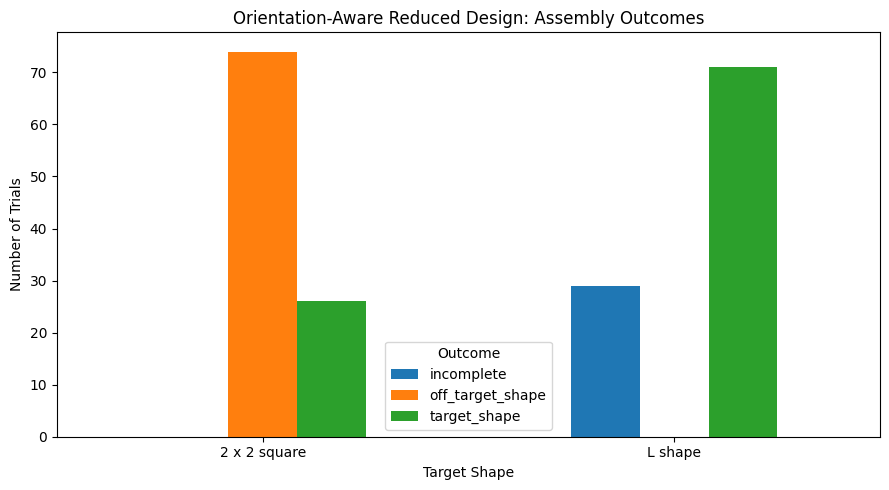

In [15]:
# ============================================================
# Step 9 continued: Running the orientation-aware assembly test
# ============================================================

# What I am doing:
# In this cell, I test whether the orientation-aware reduced designs
# assemble more reliably than the first naive reduced designs.

square_oriented_trials, square_oriented_assembly_summary = run_orientation_aware_experiment(
    square_graph,
    square_oriented_species_definitions,
    square_oriented_inventory,
    "2 x 2 square",
    trials=100
)

l_oriented_trials, l_oriented_assembly_summary = run_orientation_aware_experiment(
    l_shape_graph,
    l_oriented_species_definitions,
    l_oriented_inventory,
    "L shape",
    trials=100
)

orientation_aware_assembly_summary = pd.concat(
    [square_oriented_assembly_summary, l_oriented_assembly_summary],
    ignore_index=True
)

display(orientation_aware_assembly_summary)


pivot_orientation = orientation_aware_assembly_summary.pivot(
    index="shape",
    columns="outcome",
    values="trial_count"
).fillna(0)

ax = pivot_orientation.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Orientation-Aware Reduced Design: Assembly Outcomes")
plt.xlabel("Target Shape")
plt.ylabel("Number of Trials")
plt.xticks(rotation=0)
plt.legend(title="Outcome")
plt.tight_layout()
plt.show()

outcome,shape,naive_reduced_target_success_percent,orientation_aware_target_success_percent
0,2 x 2 square,0,26.0
1,L shape,0,71.0


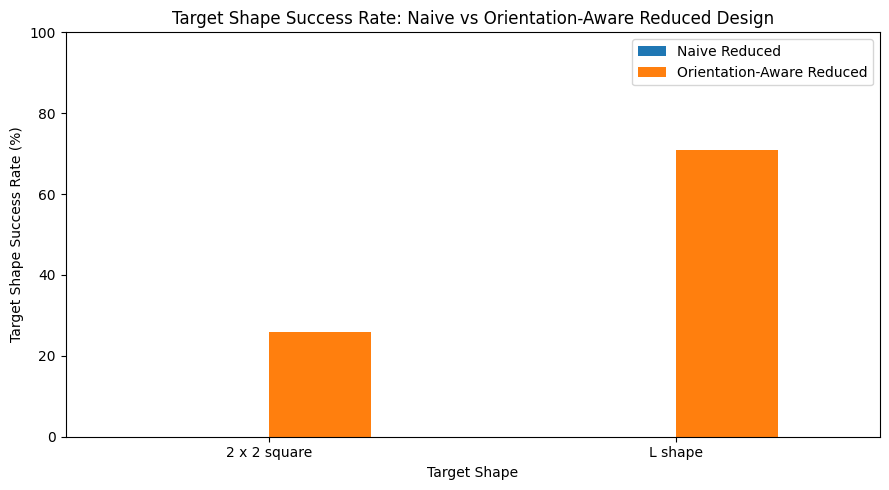

In [16]:
# ============================================================
# Step 9 continued: Comparing naive and orientation-aware reduced designs
# ============================================================

# What I am doing:
# This cell compares the earlier reduced design against the improved
# orientation-aware reduced design using target-shape success rate.

def extract_target_success(summary_table, label):
    """
    Extract target-shape success percentages from an assembly summary table.
    """
    pivot = summary_table.pivot(
        index="shape",
        columns="outcome",
        values="percent_of_trials"
    ).fillna(0).reset_index()

    if "target_shape" not in pivot.columns:
        pivot["target_shape"] = 0

    result = pivot[["shape", "target_shape"]].copy()
    result = result.rename(columns={
        "target_shape": label
    })

    return result


naive_success = extract_target_success(
    assembly_summary,
    "naive_reduced_target_success_percent"
)

orientation_success = extract_target_success(
    orientation_aware_assembly_summary,
    "orientation_aware_target_success_percent"
)

success_comparison = pd.merge(
    naive_success,
    orientation_success,
    on="shape",
    how="outer"
).fillna(0)

display(success_comparison)


plot_success_comparison = success_comparison.set_index("shape")

ax = plot_success_comparison.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Target Shape Success Rate: Naive vs Orientation-Aware Reduced Design")
plt.xlabel("Target Shape")
plt.ylabel("Target Shape Success Rate (%)")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.legend(["Naive Reduced", "Orientation-Aware Reduced"])
plt.tight_layout()
plt.show()

### Interpretation of the Orientation-Aware Model

The orientation-aware model improves the reduced design by adding local geometric constraints. Instead of allowing a reusable species to attach in any direction, the model checks whether the rotated patch pattern is compatible with neighboring blocks.

This makes the reduced design more realistic than the first version, because reusable building blocks can still appear in different orientations while preserving directional information.

The result also shows why minimal complexity design is not only about reducing the number of species. A reduced design must preserve enough local information to avoid ambiguity. In this notebook, orientation awareness is a simple way to recover some of that lost information.

This connects back to the paper’s broader design logic: candidate designs must be evaluated not only by how few building blocks they use, but also by whether they assemble reliably into the intended target structure.

## Step 10: Limitations and Connection to the Original Paper

This notebook is intentionally simplified. The goal is not to reproduce the full computational pipeline from the paper, but to build a smaller model that helps me understand the design logic behind minimal complexity self assembly.

The original paper uses a more advanced framework for inverse design. It formulates the design problem using Boolean satisfiability, where the goal is to determine whether a target shape can be assembled with a given number of species and patch colors. It then checks candidate solutions using stochastic polycube assembly simulations, and for selected designs, studies assembly behavior using patchy particle molecular dynamics simulations.

My notebook focuses on the earlier conceptual layer of this problem. I represent target shapes as grid based graphs, compare fully addressable and reduced designs, and test whether reduced designs become ambiguous under simplified stochastic assembly rules.

This means that my model captures the design tradeoff, but not the full physical behavior. It does not model molecular dynamics, temperature, bond energy, angular tolerance, torsional constraints, DNA origami geometry, or sequence level DNA interactions. These are all important parts of the original research pipeline.

Even with these limitations, the simplified model is useful because it shows why minimal complexity design is a nontrivial problem. Reducing the number of species can make a design more efficient, but it can also remove too much specificity. If the design becomes too general, it may produce incomplete, incorrect, or ambiguous assemblies.

The orientation aware model improves on the first reduced design by adding a simple version of local geometric constraint. This is still much simpler than the paper’s patchy particle and DNA nanotechnology models, but it helps show why directionality and compatibility rules matter in programmable self assembly.

Overall, this notebook helped me understand that the key question is not only whether a structure can be represented with fewer building blocks. The more important question is whether a reduced set of reusable building blocks can still guide the system toward the intended target structure reliably.

## Step 11: Final Conclusion

This notebook explored a simplified computational version of minimal complexity self assembly.

The main idea I focused on was that a target structure can be represented in different ways. A fully addressable design gives every position in the structure its own unique building block, which makes the design very specific but also increases component complexity. A reduced design tries to reuse building block types, which can make the design more efficient but may also introduce ambiguity.

Through the graph based models, I first represented target shapes as collections of connected building blocks. I then compared fully addressable designs with reduced local-pattern designs. This showed that some structures can be described with fewer reusable species, especially when different positions share similar local connection patterns.

However, the stochastic assembly tests showed that reducing the number of species alone is not enough. A design can look efficient by using fewer building blocks, but still fail to assemble reliably if the interaction rules are too general. This was an important result because it showed that lower complexity must be balanced with enough specificity to guide the assembly toward the intended target shape.

The orientation aware model improved the simplified design by adding local geometric constraints. This made the reduced design more meaningful because reusable building blocks could still appear in different orientations while preserving directional information. Although this is still much simpler than the full methods used in the original paper, it helped show why patch direction, compatibility, and assembly constraints are important in programmable self assembly.

Overall, this project helped me understand minimal complexity self assembly as both a computational design problem and a broader bio inspired systems problem. From a computer science perspective, it connects to graph representation, constraint based reasoning, stochastic testing, and optimization. From a sustainability perspective, the idea of designing structures with fewer unique components may eventually connect to more efficient materials, environmental sensing platforms, and lower resource experimental workflows.

This notebook is not a molecular simulation or a full reproduction of the paper. Instead, it is a learning based computational model that helped me understand the design tradeoff between simplicity and reliability in self assembled systems. A natural next step would be to study SAT based inverse design more directly, explore larger three dimensional target shapes, or connect the simplified model to existing tools used in DNA and RNA nanotechnology simulations.

## Reference and Academic Note

This notebook was inspired by the following paper:

Bohlin, J., Turberfield, A. J., Louis, A. A., and Šulc, P.  
*Designing the Self Assembly of Arbitrary Shapes Using Minimal Complexity Building Blocks.*

The paper studies how target self assembled structures can be designed using different levels of component complexity. At one extreme, every building block is unique. At the other extreme, a smaller set of reusable building block species is used to define the same target structure.

The original work uses methods that are much more advanced than this notebook, including SAT based inverse design, stochastic polycube assembly simulations, patchy particle molecular dynamics, and coarse grained DNA nanostructure modeling.

This notebook does not attempt to reproduce those methods. Instead, it is a student learning project that builds a simplified graph based and stochastic model to understand the main computational design tradeoff: reducing component complexity while preserving enough specificity for reliable assembly.

The purpose of this notebook is to show my developing interest in computational modeling, bio inspired systems, and sustainability connected design thinking.